In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../Dataset/cleaned_gcs_kushal.csv")
df.head()

,age,gender,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,endoscopic_images,biopsy_results,ct_scan,...,label,existing_conditions_Chronic Gastritis,existing_conditions_Diabetes,existing_conditions_Unknown,mature_mirna_id_MIR123_1,mature_mirna_id_MIR234_2,mature_mirna_id_MIR345_3,target_symbol_CDH1,target_symbol_KRAS,target_symbol_TP53
0,43,1,1,0,0,0,0,0,0,0,...,0,True,False,False,True,False,False,False,False,True
1,86,0,1,0,0,1,1,0,0,0,...,0,False,True,False,False,True,False,False,False,True
2,68,1,0,1,1,0,1,0,0,0,...,0,False,False,True,False,False,True,False,True,False
3,57,0,0,0,0,1,1,0,0,0,...,0,True,False,False,True,False,False,False,True,False
4,33,1,0,1,1,0,1,1,0,0,...,0,False,True,False,True,False,False,True,False,False


### Inspecting Real Numerical Independet Feature ###

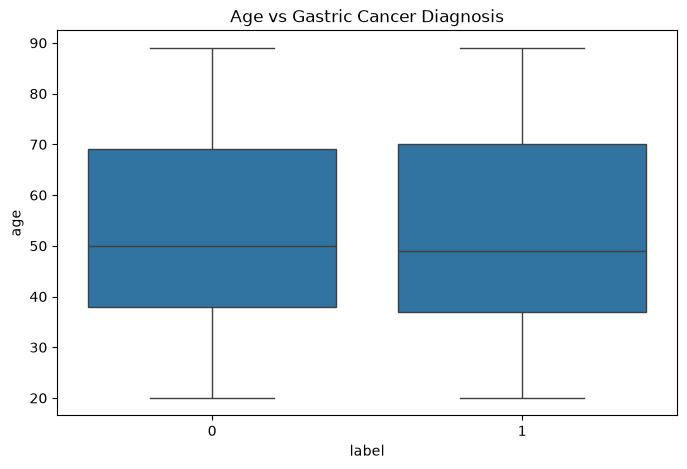

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="age", data=df)
plt.title("Age vs Gastric Cancer Diagnosis")
plt.show()

In [5]:
df.groupby("label")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,191395.0,53.270916,18.977788,20.0,38.0,50.0,69.0,89.0
1,20959.0,53.140417,19.044914,20.0,37.0,49.0,70.0,89.0


Patients with and without gastric cancer exhibit nearly identical age distributions. The similar mean, median, and spread indicate that age alone has limited predictive power.

### Correlation Analysis ###

In [11]:
corr_target = (
    df.corr(numeric_only=True)["label"]
      .drop("label")
      .sort_values(key=abs, ascending=False)
)

print(corr_target)

pita                                     0.004920
target_entrez                           -0.004889
family_history                          -0.004116
existing_conditions_Diabetes            -0.003695
smoking_habits                           0.002680
helicobacter_pylori_infection           -0.002651
existing_conditions_Unknown              0.002593
mirdb                                   -0.002420
all.sum                                 -0.002259
ct_scan                                  0.002131
age                                     -0.002050
diana_microt                             0.001800
existing_conditions_Chronic Gastritis    0.001310
alcohol_consumption                     -0.001057
microcosm                                0.001056
dietary_habits                          -0.001045
gender                                   0.001032
targetscan                              -0.000974
predicted.sum                           -0.000824
target_symbol_KRAS                       0.000787


The correlation analysis revealed that none of the features exhibit a meaningful linear relationship with the target variable (gastric cancer diagnosis). All Pearson correlation coefficients were close to zero (|r| < 0.01), indicating negligible linear association between individual features and the target. This suggests that the dataset does not contain strong linear predictors of gastric cancer, reinforcing the need for a nonlinear machine learning model such as Random Forest, which can capture complex interactions among multiple features.